In [182]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [183]:
""" !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv """

' !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv '

In [184]:
df = pd.read_csv('./data/car_fuel_efficiency.csv')
df.head(5)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

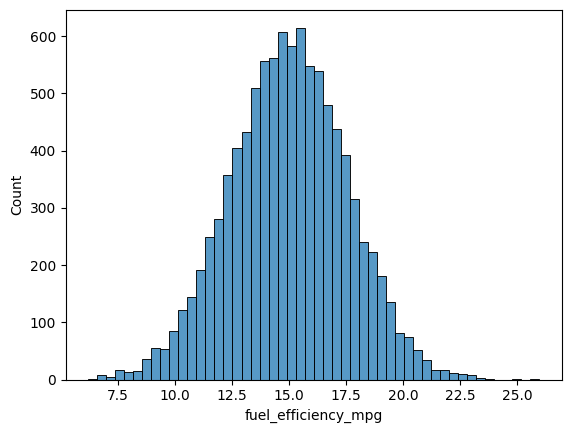

In [185]:
sns.histplot(df['fuel_efficiency_mpg'],bins=50)

In [186]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [187]:
df['horsepower'].median()

np.float64(149.0)

In [188]:
# train, val, test split
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test


df_train = df.iloc[n_train:]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [189]:
# Shuffle
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [190]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X_zero(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

def prepare_X_mean(df):
    df_num = df[base]
    mean = df_num.mean()
    df_num = df_num.fillna(mean)
    X = df_num.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred): # y is vector
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [191]:
# for 0 impute
X_train = prepare_X_zero(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_zero(df_val)
y_pred = w0 + X_val.dot(w)

print('for 0 impute:', round(rmse(y_val, y_pred), 2))

for 0 impute: 0.52


In [192]:
# for mean impute
X_train = prepare_X_mean(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_mean(df_val)
y_pred = w0 + X_val.dot(w)

print('for mean impute:', round(rmse(y_val, y_pred), 2))

for mean impute: 0.46


# regulatized LR

In [193]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [194]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_zero(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X_zero(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, round(w0,2), round(score,2))

0 28.83 0.52
0.01 24.93 0.52
0.1 11.24 0.52
1 1.73 0.52
5 0.36 0.52
10 0.18 0.52
100 0.02 0.52


# Find optimizite seed

In [195]:
score_list = []

def find_rmse_for_each_seed(df):
    seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    
    for seed in seed_list:
        n = len(df)

        n_val = int(n*0.2)
        n_test = int(n*0.2)
        n_train = n - n_val - n_test

        df_train = df.iloc[n_train:]
        df_val = df.iloc[n_train:n_train+n_val]
        df_test = df.iloc[n_train+n_val:]
        
        idx = np.arange(n)
        np.random.seed(seed)
        np.random.shuffle(idx)

        df_train = df.iloc[idx[:n_train]]
        df_val = df.iloc[idx[n_train:n_train+n_val]]
        df_test = df.iloc[idx[n_train+n_val:]]

        df_train = df_train.reset_index(drop=True)
        df_val = df_val.reset_index(drop=True)
        df_test = df_test.reset_index(drop=True)

        y_train = df_train['fuel_efficiency_mpg'].values
        y_val = df_val['fuel_efficiency_mpg'].values
        y_test = df_test['fuel_efficiency_mpg'].values

        X_train = prepare_X_zero(df_train)
        w0, w = train_linear_regression(X_train, y_train)

        X_val = prepare_X_zero(df_val)
        y_pred = w0 + X_val.dot(w)

        score = rmse(y_val, y_pred)

        score_list.append(score)

In [196]:
find_rmse_for_each_seed(df)

In [197]:
std = np.std(score_list)
round(std, 3)

np.float64(0.007)

# FINAL

In [198]:
n = len(df)

n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

df_train = df.iloc[n_train:]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

X_train = prepare_X_zero(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_val = prepare_X_zero(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)

print(r, round(w0,2), score)

100 27.09 0.5131790626923073
